In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import to_hex, ListedColormap
import numpy as np
from lifelines import KaplanMeierFitter, BreslowFlemingHarringtonFitter
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import proportional_hazard_test
from datetime import datetime, timedelta, time, date
from lifelines.plotting import plot_lifetimes
from lifelines import CoxPHFitter
from tableone import TableOne

import warnings
warnings.filterwarnings('ignore')

In [36]:
# load data
medlabel = 'io' 
df_master_io_cancer = pd.read_csv('data_io.csv') #can switch to osi or 5fu

# one hot encode cancer type
cancer_vc = df_master_io_cancer.CANCER_TYPE.value_counts()
common_cancers = cancer_vc.index
for c in common_cancers:
    df_master_io_cancer[c] = df_master_io_cancer.CANCER_TYPE==c
df_master_io_cancer['Any']=True

In [37]:
# make time dependent covariate

# grab all patients needing TDC
mask = (df_master_io_cancer['start_wvax']>df_master_io_cancer['start'])
df_master_io_cancer_first = df_master_io_cancer.loc[mask]
df_master_io_cancer_first['stop'] = df_master_io_cancer_first['start_wvax']
df_master_io_cancer_first['dead']=False
df_master_io_cancer_first['VAX']=False

df_master_io_cancer_last = df_master_io_cancer.loc[mask]
df_master_io_cancer_last['start']=df_master_io_cancer_last['start_wvax']

df_master_io_cancer_TDC = pd.concat([df_master_io_cancer_first,
                                     df_master_io_cancer_last,
                                     df_master_io_cancer.loc[~mask]])

In [38]:
# table 1
myOrder = {'CANCER_TYPE':list(common_cancers),'YEAR':list(range(2017,2022))}
mytable = TableOne(df_master_io_cancer, 
                   columns=['CANCER_TYPE','CONCUR_CHEMO','CONCUR_CTLA4','STAGE_DX_INT','AGE','Male','RACE_SIMPLE','ETHNICITY_SIMPLE','YEAR','ecog_parsed','dt_med-dx','VAX'], 
                   categorical=['CANCER_TYPE','CONCUR_CHEMO','CONCUR_CTLA4','STAGE_DX_INT','Male','RACE_SIMPLE','ETHNICITY_SIMPLE','ecog_parsed','YEAR'],
                   continuous=['AGE','dt_med-dx'],
                   order=myOrder,
                   groupby='VAX', pval=True)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(mytable)

Grouped by VAX                                                        
                                                                                  Missing         Overall           False            True P-Value
n                                                                                                    8368            6869            1499        
CANCER_TYPE, n (%)      Non-Small Cell Lung Cancer                                            2596 (31.0)     2181 (31.8)      415 (27.7)  <0.001
                        Melanoma                                                              1021 (12.2)      871 (12.7)      150 (10.0)        
                        Esophagogastric Cancer                                                 833 (10.0)       600 (8.7)      233 (15.5)        
                        Bladder Cancer                                                          768 (9.2)       625 (9.1)       143 (9.5)        
                        Endometrial Cancer                                                      629 (7.5)       509 (7.4)       120 (8.0)        
                        Renal Cell Carcinoma                                                    516 (6.2)       421 (6.1)        95 (6.3)        
                        Cancer of Unknown Primary                                               509 (6.1)       429 (6.2)        80 (5.3)        
                        Colorectal Cancer                                                       391 (4.7)       331 (4.8)        60 (4.0)        
                        Soft Tissue Sarcoma                                                     390 (4.7)       317 (4.6)        73 (4.9)        
                        Breast Cancer                                                           385 (4.6)       304 (4.4)        81 (5.4)        
                        Hepatobiliary Cancer                                                    330 (3.9)       281 (4.1)        49 (3.3)        
CONCUR_CHEMO, n (%)     False                                                                 6223 (74.4)     5270 (76.7)      953 (63.6)  <0.001
                        True                                                                  2145 (25.6)     1599 (23.3)      546 (36.4)        
CONCUR_CTLA4, n (%)     False                                                                 7363 (88.0)     6023 (87.7)     1340 (89.4)   0.072
                        True                                                                  1005 (12.0)      846 (12.3)      159 (10.6)        
STAGE_DX_INT, n (%)     0.0                                                                     281 (3.4)       220 (3.2)        61 (4.1)   0.243
                        1.0                                                                    983 (11.7)      809 (11.8)      174 (11.6)        
                        2.0                                                                   1007 (12.0)      848 (12.3)      159 (10.6)        
                        3.0                                                                   2302 (27.5)     1882 (27.4)      420 (28.0)        
                        4.0                                                                   3732 (44.6)     3056 (44.5)      676 (45.1)        
                        None                                                                     63 (0.8)        54 (0.8)         9 (0.6)        
AGE, mean (SD)                                                                          0     64.5 (12.8)     64.3 (12.9)     65.6 (12.2)  <0.001
Male, n (%)             False                                                                 4078 (48.7)     3325 (48.4)      753 (50.2)   0.210
                        True                                                                  4290 (51.3)     3544 (51.6)      746 (49.8)        
RACE_SIMPLE, n (%)      Asian-Far East/Indian Subcont                                           623 (7.4)       495 (7.2)       128 (

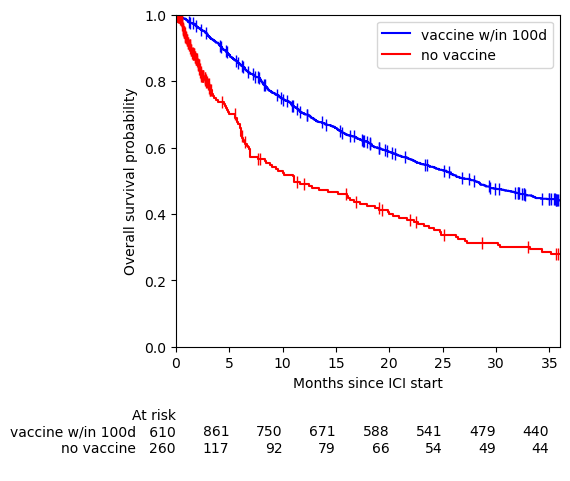

In [26]:
# Fig 1 Kaplan-Meier analysis (TDC)
daysinmo = 30.14

fig, ax = plt.subplots(figsize=(5.8, 5))

c = 'Any' # can replace with, for example, 'Any','Melanoma','Non-Small Cell Lung Cancer'
y = 2021
mask = (df_master_io_cancer_TDC[c]) & (df_master_io_cancer_TDC['YEAR']==y)
temp = df_master_io_cancer_TDC[mask]

temp = temp[temp.stop>(temp.start)]

kmf4 = KaplanMeierFitter(label='vaccine w/in 100d')
kmf4.fit(temp[temp['VAX']]['stop']/daysinmo, 
        temp[temp['VAX']]['dead'],
        entry=temp[temp['VAX']]['start']/daysinmo)
kmf4.plot(ci_show=False,color='blue',style='-',show_censors=True,censor_styles={'ms': 8, 'marker': '|'},ax=ax)

kmf2 = KaplanMeierFitter(label='no vaccine')
kmf2.fit(temp[~temp['VAX'] & ~temp['OLDVAX']]['stop']/daysinmo, 
        temp[~temp['VAX'] & ~temp['OLDVAX']]['dead'],
         entry=temp[~temp['VAX'] & ~temp['OLDVAX']]['start']/daysinmo)
kmf2.plot(ci_show=False,color='red',show_censors=True,censor_styles={'ms': 8, 'marker': '|'},ax=ax)

ax.set_xlabel("Months since ICI start")
ax.set_ylabel("Overall survival probability")

ax.set_xlim(0,36)
ax.set_ylim(0,1)
add_at_risk_counts(kmf4,kmf2,rows_to_show=['At risk'])

plt.tight_layout()
plt.savefig("covid_vaccine_myOS_"+medlabel+'_'+c+'_'+str(y)+".pdf", format='pdf', bbox_inches='tight')

plt.show()

In [44]:
df_master_io_cancer['concurrent chemo'] = df_master_io_cancer['CONCUR_CHEMO']
df_master_io_cancer['no concurrent chemo'] = ~df_master_io_cancer['CONCUR_CHEMO']

In [40]:
# Forest plots

results = []

df_master_io_cancer_TDC['concurrent chemo'] = df_master_io_cancer_TDC['CONCUR_CHEMO']
df_master_io_cancer_TDC['no concurrent chemo'] = ~df_master_io_cancer_TDC['CONCUR_CHEMO']

# Define subgroups in desired order
pancan_set = ['Any','concurrent chemo','no concurrent chemo']
subgroups = pancan_set + list(common_cancers)

for c in subgroups:
    mask = (df_master_io_cancer_TDC[c]) &\
        (df_master_io_cancer_TDC['YEAR']==y)
    temp = df_master_io_cancer_TDC[mask]
    
    temp = temp[temp.stop > temp.start_wvax]
    
    cph = CoxPHFitter()
    cols = ['VAX', 'OLDVAX', 'stop', 'dead', 'STAGE_DX_INT', 'ecog_parsed', 'dt_med-dx', 'AGE', 'start']
    if c in pancan_set and len(common_cancers)>1:
        cols += list(common_cancers[:-1])

    # fuss with columns for multivariate analysis to avoid singular matrix
    if c=='concurrent chemo':
        cols.remove('Renal Cell Carcinoma')
        cols.remove('Melanoma')
        #cols.remove('Hepatobiliary Cancer')
    if not c in ['Endometrial Cancer','Breast Cancer']:
        cols += ['Male'] # reviewer 1 comment
        
    temp = temp[cols].dropna()
    if len(temp) < 20:
        continue  # skip small groups
    
    try:
        cph.fit(temp, duration_col='stop', event_col='dead', entry_col='start')
        summary = cph.summary
        
        for var in ['VAX', 'OLDVAX']:
            if var in summary.index:
                hr = np.exp(summary.loc[var, 'coef'])
                ci_lower = np.exp(summary.loc[var, 'coef lower 95%'])
                ci_upper = np.exp(summary.loc[var, 'coef upper 95%'])
                pval = summary.loc[var, 'p']
                if hr<10:
                    results.append({
                        'Cancer': c,
                        'Variable': var,
                        'HR': hr,
                        'CI_lower': ci_lower,
                        'CI_upper': ci_upper,
                        'p': pval
                    })
                else:
                    results.append({
                        'Cancer': c,
                        'Variable': var,
                        'HR': np.nan,
                        'CI_lower': np.nan,
                        'CI_upper': np.nan,
                        'p': pval
                    }) 
    except:
        print('failed for '+c)

# --- Build results DataFrame ---
results_df = pd.DataFrame(results)

# Preserve original order of cancers/subgroups
results_df['Cancer'] = pd.Categorical(results_df['Cancer'], categories=subgroups, ordered=True)

In [41]:
results_df

,Cancer,Variable,HR,CI_lower,CI_upper,p
0,Any,VAX,0.505758,0.414785,0.616683,1.607212e-11
1,Any,OLDVAX,0.632001,0.500706,0.797725,1.124576e-04
2,concurrent chemo,VAX,0.410617,0.294588,0.572346,1.493489e-07
3,concurrent chemo,OLDVAX,0.427251,0.283836,0.643128,4.593902e-05
4,no concurrent chemo,VAX,0.521174,0.405251,0.670257,3.835195e-07
5,no concurrent chemo,OLDVAX,0.709339,0.531165,0.947280,1.996821e-02
6,Non-Small Cell Lung Cancer,VAX,0.381469,0.259000,0.561847,1.070207e-06
7,Non-Small Cell Lung Cancer,OLDVAX,0.601880,0.384763,0.941513,2.615079e-02
8,Melanoma,VAX,0.339955,0.150856,0.766093,9.248645e-03
9,Melanoma,OLDVAX,0.546809,0.217259,1.376234,1.999001e-01


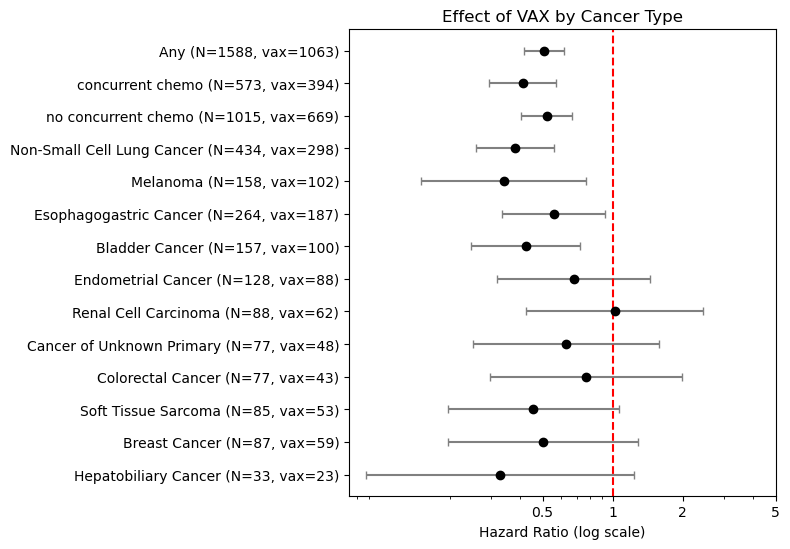

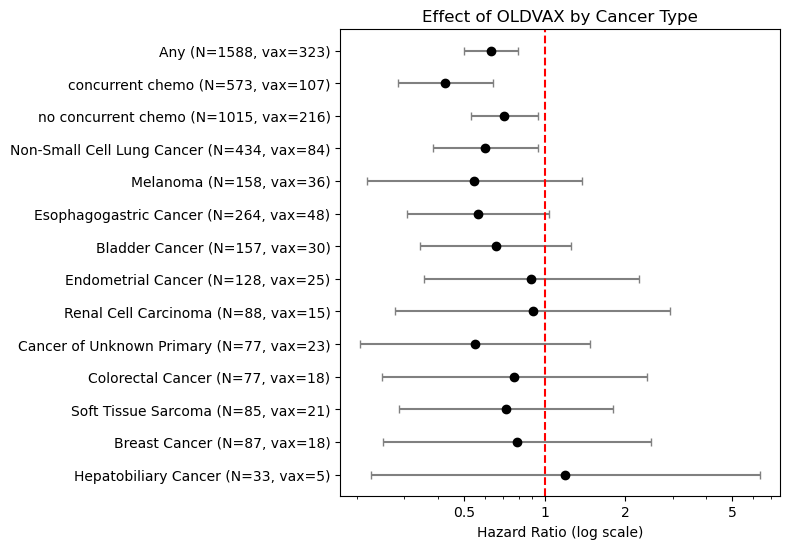

In [45]:
# --- Build subgroup counts ---
#subgroups = ['Any'] + list(common_cancers)
counts = []

for c in subgroups:
    temp = df_master_io_cancer[
        (df_master_io_cancer[c]) &
        (df_master_io_cancer['YEAR']==y)
    ]
    n_total = len(temp)
    n_vax = temp['VAX'].sum()
    n_oldvax = temp['OLDVAX'].sum()
    counts.append({'Cancer': c, 'N_total': n_total, 'N_vax': n_vax, 'N_oldvax': n_oldvax})

counts_df = pd.DataFrame(counts)

# --- Normalize merge key ---
results_df['Cancer'] = results_df['Cancer'].astype(str).str.strip()
counts_df['Cancer'] = counts_df['Cancer'].astype(str).str.strip()

# --- Merge safely ---
results_df = results_df.merge(counts_df, on='Cancer', how='left')

# --- Check merge success ---
missing = results_df[results_df['N_total'].isna()]
if not missing.empty:
    print("⚠️ Warning: Some cancers missing counts:")
    print(missing[['Cancer']])

# --- Preserve order ---
results_df['Cancer'] = pd.Categorical(results_df['Cancer'], categories=subgroups, ordered=True)

results_vax = results_df[results_df['Variable'] == 'VAX'].sort_values('Cancer')
results_oldvax = results_df[results_df['Variable'] == 'OLDVAX'].sort_values('Cancer')

# --- Forest plot function ---
def make_forest_plot(data, title, filename, vax_col):
    fig, ax = plt.subplots(figsize=(8, len(data) / 2.5))
    y_positions = np.arange(len(data))

    # Build y-axis labels safely
    label_col = [
        f"{row['Cancer']} (N={int(row.get('N_total', 0))}, vax={int(row.get(vax_col, 0))})"
        for _, row in data.iterrows()
    ]

    # Plot hazard ratios with 95% CI
    ax.errorbar(
        data['HR'],
        y_positions,
        xerr=[data['HR'] - data['CI_lower'], data['CI_upper'] - data['HR']],
        fmt='o',
        color='black',
        ecolor='gray',
        capsize=3,
    )

    # Formatting
    ax.axvline(1, color='red', linestyle='--')
    ax.set_yticks(y_positions)
    ax.set_yticklabels(label_col)
    ax.set_xscale('log')
    ax.set_xticks([0.5, 1, 2, 5])
    ax.set_xticklabels(['0.5', '1', '2', '5'])
    ax.invert_yaxis()  # keeps "Any" on top
    ax.set_xlabel('Hazard Ratio (log scale)')
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(filename, format='pdf')
    plt.show()

# --- Create plots ---
make_forest_plot(
    results_vax,
    "Effect of VAX by Cancer Type",
    f"covid_myforest_vax_{medlabel}_{starttime}_{stoptime}.pdf",
    vax_col='N_vax'
)

make_forest_plot(
    results_oldvax,
    "Effect of OLDVAX by Cancer Type",
    f"covid_myforest_oldvax_{medlabel}_{starttime}_{stoptime}.pdf",
    vax_col='N_oldvax'
)

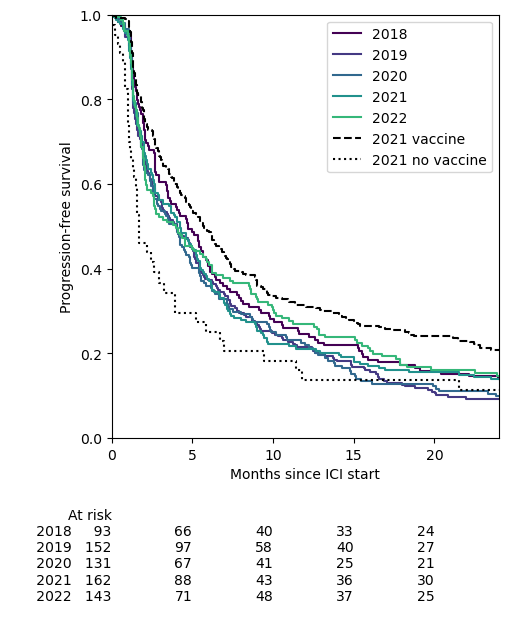

In [60]:
# PFS analysis
df_master_io_cancer_pfs = pd.read_csv('data_pfs_io.csv')

fig, ax = plt.subplots(figsize=(5, 5.5))

# by year (no vaccine stratification)
cmap = cm.get_cmap('viridis')
colors = [to_hex(cmap(x)) for x in np.linspace(0, 1, 7)]

years = range(2018,2023)
kmfs = [None]*len(years)
for i, y in enumerate(years):
    starttime = pd.Timestamp(y, 1, 1)
    stoptime = pd.Timestamp(y+1, 1, 1)
    mask = (df_master_io_cancer_pfs['CANCER_TYPE']=='Non-Small Cell Lung Cancer') & (df_master_io_cancer_pfs['YEAR']==y)
    mask = mask & (df_master_io_cancer_pfs['dt_med-dx']<=90)
    mask = mask & (df_master_io_cancer_pfs.STAGE_DX_INT==4)
    temp = df_master_io_cancer_pfs[mask]
    
    temp = temp[(temp.stop_pfs>temp.start)]# & (temp.stop>100)]
    
    kmfs[i] = KaplanMeierFitter(label=y)
    kmfs[i].fit(temp['stop_pfs']/daysinmo, 
            temp['progressed'],
             entry=temp['start']/daysinmo)
    kmfs[i].plot(ci_show=False,color=colors[i],ax=ax)

# 2021 graphs
y=2021
temp = df_master_io_cancer_pfs[(df_master_io_cancer_pfs['CANCER_TYPE']=='Non-Small Cell Lung Cancer') &\
                            (df_master_io_cancer_pfs['YEAR']==y)]    
temp = temp[(temp.stop_pfs>temp.start)]# & (temp.stop>100)]

kmf1 = KaplanMeierFitter(label='2021 vaccine')
kmf1.fit(temp[temp.VAX]['stop_pfs']/daysinmo, 
        temp[temp.VAX]['progressed'],
         entry=temp[temp.VAX]['start']/daysinmo)
kmf1.plot(ci_show=False,color='k',style='--',ax=ax)

kmf2 = KaplanMeierFitter(label='2021 no vaccine')
kmf2.fit(temp[~temp.VAX & ~temp.OLDVAX]['stop_pfs']/daysinmo, 
        temp[~temp.VAX & ~temp.OLDVAX]['progressed'],
         entry=temp[~temp.VAX & ~temp.OLDVAX]['start']/daysinmo)
kmf2.plot(ci_show=False,color='k',style=':',ax=ax)

ax.set_xlabel("Months since ICI start")
ax.set_ylabel("Progression-free survival")

ax.set_xlim(0,24)
ax.set_ylim(0,1)
fitters = kmfs
labels = [f"{years[i]}" for i in range(len(fitters))]
add_at_risk_counts(*kmfs,labels=labels,rows_to_show=['At risk'])

#plt.tight_layout()
plt.savefig("covid_vaccine_myPFS_year_"+medlabel+'_'+c+"_.pdf", format='pdf', bbox_inches='tight')

plt.show()